##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 3 DO LABORATORIUM 1</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Regresja liniowa i logistyczna</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">Regresja wielomianowa</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 3

W tym przykładzie zostaną przeanalizowane dane, które nie mają trendu liniowego. Okazuje się jednak, że mając model liniowy można tego dokonać na tego typie danych wejściowych poprzez dodanie potęg każdej cechy w postaci nowej cechy i poddaniu treningowi takiego zestawu cech - jest to regresja wielomianowa (polynomial regression).
Na podstawie biblioteki Scikit-Learn i klasy PolynomialFeatures można przeanalizować zmianę położenia w czasie ciała wyrzuconego do góry z prędkością początkową $23~m/s$ z wysokości $8~m$ nad powierzchnią Ziemi.
Rozpoczynamy jak poprzednio od importu potrzebnych bibliotek

In [ ]:
# Import podstawowych bibliotek języka Python
import numpy as np  # operacje numeryczne
import matplotlib  # wykresy i ich ustawienia
import matplotlib.pyplot as plt  # tworzenie wykresu

oraz wygenerowania odpowiednich danych do zakładanego przypadku oraz ich wizualizację.

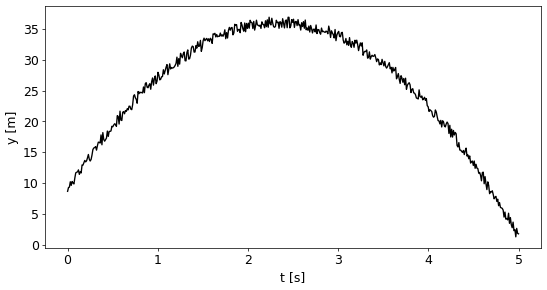

In [2]:
dataset_training_size = 500
t = x_t = np.linspace(0, 5, dataset_training_size).astype(np.float32)
noise = 2*np.random.rand(dataset_training_size).astype(np.float32)
#y = h0+vo*t-0.5*g*t^2
h0 = 8.0
v0 = 23
g = 9.81

y=h0+v0*t-0.5*g*t**2+noise

# Wizualizacja wygenerowanych danych
# Ustawienia związane z wyświetlaniem
matplotlib.rcParams.update({'font.size': 14})
f = plt.figure(figsize=(10, 5), dpi=64)
f1 = f.add_subplot(111)
f1.set_xlabel('t [s]')
f1.set_ylabel('y [m]')
f1.plot(t,y, "k")
plt.show()

Następnie należy zaimportować klasę <i>PolynomialFeatures</i> oraz stworzyć jej obiekt, podając jako argument stopień wielomianu. Na tym etapie należy zadbać o odpowiednie przygotowanie formatu danych wejściowych oraz odpowiednie przekształcenie cech. Mając to wszystko zrealizowane prawidłowo, można wywołać metodę regresji liniowej, która była wykorzystywana w przykładzie 1.

In [3]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
t = t.reshape(dataset_training_size,1)
y = y.reshape(dataset_training_size,1)
t_poly = poly_features.fit_transform(t) #obiekt ten zawiera teraz oryginalną cechę t oraz jej kwadrat

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(t_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[8.987614] [[23.019447 -4.91206 ]]


Uzyskane wartości współczynników można porównać z tymi z założeń początkowych.

# Zadania do wykonania

<p><b>Zadanie 1</b></p>
a) W jaki sposób zaszumienie będzie wpływało na wartości wyznaczanych parametrów? Sprawdź wpływ dopasowania wielomianów wyższych stopni do tych danych.

b) Wykorzystaj klasę PolynomialFeatures do wyuczenia współczynników dla wielomianu trzeciego stopnia. Przedstaw dane rzeczywiste oraz te wyuczone z modelu na jednym rysunku. 

Stopień 1: wyraz wolny = 28.76, współczynniki = [-1.6726254]
Stopień 2: wyraz wolny = 8.65, współczynniki = [22.509634 -4.836451]
Stopień 3: wyraz wolny = 8.16, współczynniki = [23.707762   -5.436109    0.07995408]
Stopień 15: wyraz wolny = 28.25, współczynniki = [-5.0307751e-13  1.1670842e-10 -1.1427297e-11 -3.6041330e-11
 -1.3126496e-10 -4.6532103e-10 -1.6019106e-09 -5.3212048e-09
 -1.6853191e-08 -4.9847159e-08 -1.3247160e-07 -2.9073027e-07
 -4.0521641e-07  1.4354939e-07 -1.0838999e-08]


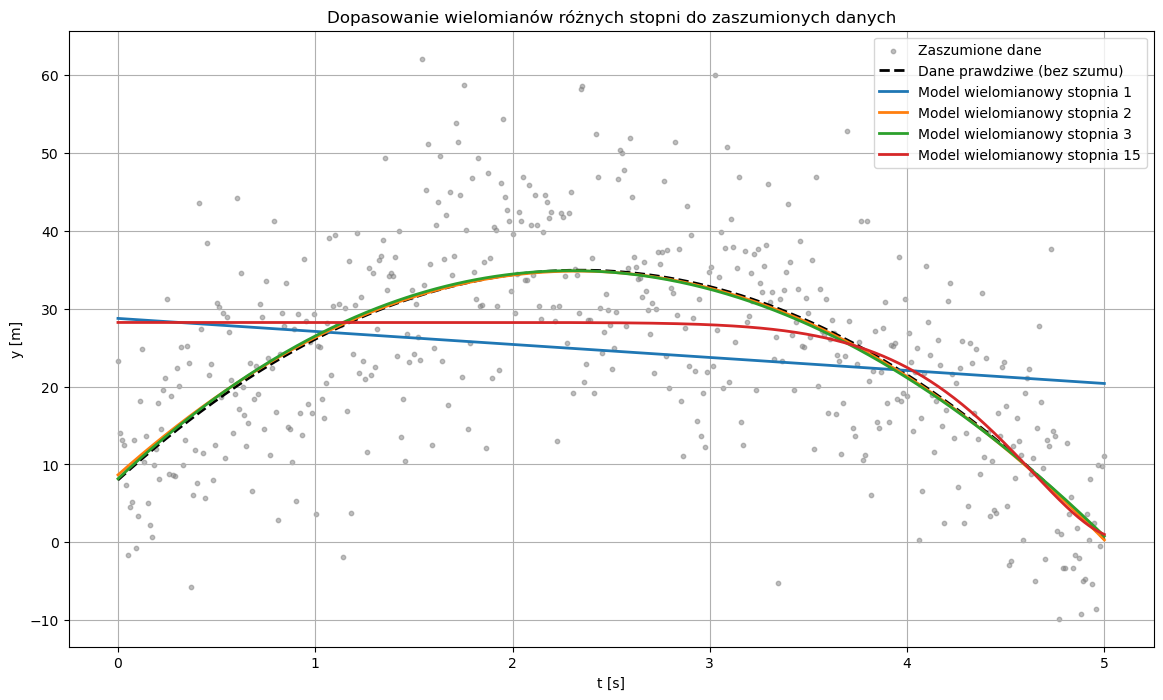

In [1]:
# Zadanie 1a i 1b
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Przygotowanie danych z większym i mniejszym szumem dla lepszego pokazania
dataset_training_size = 500
t = np.linspace(0, 5, dataset_training_size).astype(np.float32)
# Generowanie różnych poziomów szumu
noise_low = 0.5 * np.random.randn(dataset_training_size).astype(np.float32)
noise_high = 10 * np.random.randn(dataset_training_size).astype(np.float32)

h0, v0, g = 8.0, 23.0, 9.81
y_true = h0 + v0*t - 0.5*g*(t**2)
y_noisy = y_true + noise_high

t = t.reshape(dataset_training_size, 1)

# Dopasowanie wielomianów różnych stopni t_poly_1, 2, 3, 15
degrees = [1, 2, 3, 15]

plt.figure(figsize=(14, 8))
plt.scatter(t, y_noisy, color='gray', s=10, alpha=0.5, label='Zaszumione dane')
plt.plot(t, y_true, color='black', linewidth=2, label='Dane prawdziwe (bez szumu)', linestyle='--')

for d in degrees:
    poly_features = PolynomialFeatures(degree=d, include_bias=False)
    t_poly = poly_features.fit_transform(t)
    
    lin_reg = LinearRegression()
    lin_reg.fit(t_poly, y_noisy)
    
    print(f"Stopień {d}: wyraz wolny = {lin_reg.intercept_:.2f}, współczynniki = {lin_reg.coef_}")
    
    y_pred = lin_reg.predict(t_poly)
    plt.plot(t, y_pred, linewidth=2, label=f'Model wielomianowy stopnia {d}')

plt.xlabel('t [s]')
plt.ylabel('y [m]')
plt.legend()
plt.title('Dopasowanie wielomianów różnych stopni do zaszumionych danych')
plt.grid(True)
plt.show()

![stopka.svg](stopka.svg)

### Wnioski na podstawie przeprowadzonych eksperymentów:

1. **Wpływ zaszumienia na parametry (Zadanie 1a):**
   Jeśli szum w danych jest stosunkowo niski, współczynniki wielomianu 2. stopnia ($t$ i $t^2$) bardzo dokładnie przybliżają parametry wejściowe układu fizycznego ($h_0=8$, $v_0=23$, $a=-0.5g=-4.905$).
   Kiedy dodamy duży poziom szumu, wyznaczane parametry ulegają pewnemu odkształceniu (odchylenia od prawdziwych wartości w zależności od losowego wpływu rozkładu szumu). Model ma problem, ponieważ "próbuje" zminimalizować błąd także dla punktów zniekształconych i w ten sposób oryginalne współczynniki ulegają "zakłóceniu". 

2. **Dopasowanie wielomianów wyższych stopni (Zadanie 1a/1b):**
   - **Stopień 1:** Zwykła regresja liniowa nie jest w stanie uchwycić zjawiska ukształtowanego jak parabola (rzut ukośny) – mamy do czynienia ze zjawiskiem *underfittingu (niedouczenia)*.
   - **Stopień 2:** Bardzo dobrze odzwierciedla naturę fizycznego układu pomimo zaszumienia, parametry nie są idealne ale leżą stosunkowo blisko ideału ($h_0 \approx 8$, $v_0 \approx 23$, przelicznik przy potędze $t^2 \approx -4.9$).
   - **Stopień 3 (Zadanie 1b):** Krzywa dla 3 stopnia przebiega bardzo podobnie jak dla stopnia 2 (wagi dla potęgi $t^3$ są z reguły tak małe, że niemalże zerowe – np. $0.08$). Oznacza to, że model stara się lekko dopasować do szumu, ale bazowe równanie paraboli dominuje.
   - **Stopień 15:** Zjawisko klasycznego **overfittingu (przeuczenia)**. Jeśli użyjemy ogromnych wielomianów (np. 15 i wyżej stopnia) – na wykresie będzie widać jak funkcja zaczyna nadmiernie skręcać pomiędzy poszczególnymi odchyłkami zaszumienia (zaczyna "wężykować"). Współczynniki prą w absurdalnie duże rzędy i nie mają żadnego powiązania z rzeczywistymi zjawiskami fizycznymi.